# **14장. 감성 분석 모델**  

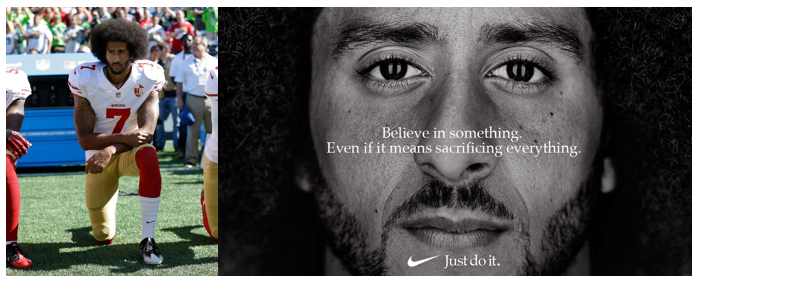

2018년, 스포츠 브랜드 NIKE는 ‘**Just Do It**’ 캠페인 30주년을 맞아 NFL 스타  **콜린 캐퍼닉**을 광고 모델로 기용했습니다.

당시 캐퍼닉은 NFL 경기 전 미국 국가 제창을 거부하고, 경찰의 인종 차별에 항의하는 시위를 주도해 논란을 일으켰습니다.

이 광고의 핵심 메시지는 다음과 같았습니다.

**Believe in something. Even if it means sacrificing everything** (모든 것을 희생해서라도 신념을 지켜라)

광고는 뜨거운 반응을 불러일으켰습니다.
* 젊은 세대는 사회적 정의를 지지한 용기 있는 결정으로 호평했지만
* 보수 성향 소비자들은 강하게 반발했고 나이키 불매 운동까지 일어났습니다.

나이키는 어떻게 대응했을까요?
* 트위터, 페이스북, 인스타그램 등 SNS 채널에서 광고에 대한 방대한 댓글 데이터를 수집하여 **빅데이터 감성 분석**을 진행했습니다.

* 분석 결과, 전반적으로 긍정적 감정 표현이 더 많았고,
* 특히 나이키의 핵심 타깃인 MZ 세대에서는 광고 이전보다 긍정 비율이 더 증가하는 것으로 나타났습니다.

이러한 분석을 토대로 나이키는 캠페인을 지속했고, 결과는 성공적이었습니다.
* 캠페인 직후 주가가 일시적으로 하락했지만 일주일 내에 반등했고, 온라인 판매량은 전년 대비 30% 증가했습니다.




---



In [ ]:
!pip install koreanize_matplotlib
import koreanize_matplotlib
import pandas as pd; import numpy as np; import matplotlib.pyplot as plt; import random
import tensorflow as tf; from tensorflow import keras; import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tensorflow.keras.optimizers import Adam
from keras.models import Sequential
from keras.layers import Input, Dense, Embedding, SimpleRNN, GRU, LSTM, Dropout, GlobalAveragePooling1D, Flatten
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import Callback, EarlyStopping
import warnings; warnings.filterwarnings('ignore')

[실습 14-01]

In [ ]:
df=pd.read_csv('식당_리뷰.csv', encoding='cp949')
print(df); print()

# 감정 유형별 빈도 계산
print(df['label'].value_counts()) # 0=부정, 1=긍정

# 댓글과 감성 분리
texts=df["review"].astype(str).values
labels=df["label"].values

      label                                             review
0         1                         고기가 두껍지 않아 금방 익혀서 먹을 수 있어요
1         0  페퍼로니 모차렐라 반반 먹었는데 별로. 맥주도 그냥 그랬다. 분위기도 별로... 재...
2         0  맛 집이라고  해서 왔는데 진짜 실망입니다  배가 너무 고파서 왔는데도    돈이 ...
3         1                         이 집 흑돼지 정말 맛있습니다 굿 유명할만합니다
4         0  계산하려는데 저희 일행 보는 앞에서 음식 재사용 하려고 빼놓더라고요... 절대 안 ...
...     ...                                                ...
4995      0  주문하다가 나왔어요. 입구에선 주방이 열었다고 해서 들어갔는데 주문받으시는 분이 너...
4996      1  화이트라고도 불리는 라테가 맛있어요. 커피 따로 우유 따로 아닌 진짜 라테 맛! 생...
4997      0  머리카락? 음식 하다 보면 나올 수 있지요 그런데 대처가 너무 아쉬웠어요 미안하다는...
4998      1                       딱 내가 좋아하는 스타일의 멋과 맛이 공존하는 집!
4999      1            버섯과 고기를 구어서 쌈에 싸서 어리굴젓과 파채를 올려먹으면 금상첨화.

[5000 rows x 2 columns]

label
1    2618
0    2382
Name: count, dtype: int64


[실습 14-02]

In [ ]:
tokenizer = Tokenizer()   # 기본 설정(구두점 제거)
tokenizer.fit_on_texts(texts)
text_encoded = tokenizer.texts_to_sequences(texts)

for i in range(5): # 처음 5개 댓글의 인덱스 시퀀스 출력
  print(f"댓글 {i}: {text_encoded[i]}"); print()

print("인코딩 딕셔너리")
print(tokenizer.index_word); print()

vocab_size=len(tokenizer.word_index) + 1  # 0은 패딩용 특수 목적 토큰
print("토큰 수:", vocab_size)


댓글 0: [211, 6615, 473, 692, 4138, 25, 16, 74]

댓글 1: [1903, 4139, 1605, 37, 34, 1098, 8, 1606, 89, 34, 160, 303, 1242]

댓글 2: [3, 693, 85, 279, 10, 980, 885, 1, 6616, 4140, 981, 1, 814, 6617, 4141, 6618]

댓글 3: [33, 19, 2349, 4, 113, 220, 6619]

댓글 4: [6620, 1904, 2350, 694, 886, 41, 6621, 6622, 6623, 134, 2, 815, 1099, 6624]

인코딩 딕셔너리
{1: '너무', 2: '안', 3: '맛', 4: '정말', 5: '맛있어요', 6: '맛이', 7: '다', 8: '그냥', 9: '맛은', 10: '진짜', 11: '좀', 12: '잘', 13: '맛도', 14: '거', 15: '먹고', 16: '수', 17: '듯', 18: '곳', 19: '집', 20: '더', 21: '한', 22: '것', 23: '많이', 24: '왜', 25: '먹을', 26: '좋아요', 27: '게', 28: '가격', 29: '맛있고', 30: '있는', 31: '다른', 32: '좋은', 33: '이', 34: '별로', 35: '좋고', 36: '맛있는', 37: '먹었는데', 38: '맛있었어요', 39: '줄', 40: '또', 41: '음식', 42: '맛있게', 43: '같아요', 44: '엄청', 45: '먹는', 46: '여기', 47: '두', 48: '고기', 49: '갔는데', 50: '커피', 51: '맛있음', 52: '맛있다', 53: '양이', 54: '못', 55: '분위기', 56: '없고', 57: '갈', 58: '양도', 59: '대비', 60: '가격이', 61: '건', 62: '서비스', 63: '없음', 64: '자주', 65: '때', 66: '않고', 67: '그', 68: '없

[실습 14-03]

In [ ]:
# 리뷰의 최대 길이 계산
seq_length = max(len(seq) for seq in text_encoded)
print("최대 길이=", seq_length); print()

# 패딩 처리
X = pad_sequences(text_encoded,
                  maxlen=seq_length,
                  padding='pre')
print("X shape:", X.shape)
print(X); print()

y=labels
print("y shape:", y.shape)
print(y)

최대 길이= 34

X shape: (5000, 34)
[[    0     0     0 ...    25    16    74]
 [    0     0     0 ...   160   303  1242]
 [    0     0     0 ...  6617  4141  6618]
 ...
 [    0     0     0 ...    82   198 20484]
 [    0     0     0 ...     6 20486    19]
 [    0     0     0 ... 20491 20492  6418]]

y shape: (5000,)
[1 0 0 ... 0 1 1]


[실습 14-04]

In [ ]:
#  랜덤 시드 고정 (결과 일관성 보장)
SEED = 42; np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

# 데이터 분할
x_train, x_test, y_train, y_test, x_train_text, x_test_text  = train_test_split(
    X, y, texts, test_size=0.2, random_state=SEED)

print("x_train.shape=", x_train.shape)
print("y_train.shape=", y_train.shape)
print("x_test.shape=", x_test.shape)
print("y_test.shape=", y_test.shape)

x_train.shape= (4000, 34)
y_train.shape= (4000,)
x_test.shape= (1000, 34)
y_test.shape= (1000,)


[실습 14-05]

In [ ]:
embedding_dim=64 # 임베딩 차원

감성=Sequential([
    Input(shape=(seq_length,)),       # shape에 주의
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    GRU(64, return_sequences=False),  # 마지막 스텝의 출력만 사용
    Dropout(0.2),
    Dense(2, activation='softmax')    # 2개의 감정 유형
    ])

early_stop=EarlyStopping(monitor="val_loss",
                         patience=5, restore_best_weights=True )

감성.compile(optimizer=Adam(learning_rate=0.0001),  # 안정적 학습을 위해 학습율을 낮게 설정
           loss='sparse_categorical_crossentropy',  # 타깃이 라벨인코딩이므로 "sparse" 사용
           metrics=['accuracy'])

history=감성.fit(x_train, y_train,
               epochs=50,
               validation_data=(x_test, y_test),
               callbacks=[early_stop])

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.5425 - loss: 0.6906 - val_accuracy: 0.5650 - val_loss: 0.6872
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6110 - loss: 0.6758 - val_accuracy: 0.6340 - val_loss: 0.6653
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7955 - loss: 0.5438 - val_accuracy: 0.8320 - val_loss: 0.4427
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9065 - loss: 0.3104 - val_accuracy: 0.8720 - val_loss: 0.3659
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9510 - loss: 0.1947 - val_accuracy: 0.8590 - val_loss: 0.3506
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9712 - loss: 0.1306 - val_accuracy: 0.8740 - val_loss: 0.3346
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9818 - loss: 0.0933 - val_accuracy: 0.8720 - val_loss: 0.3268
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9895 - loss: 0.0685 - val_accura

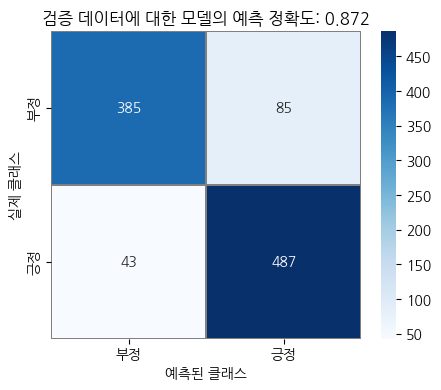

In [ ]:
class_labels=["부정", "긍정"]     # 감정 클래스 이름(순서에 주의: 0=부정, 1=긍정)
y_prob = 감성.predict(x_test, verbose=0)
y_pred=np.argmax(y_prob, axis=1) # 예측 클래스

# 정확도 및 혼동 행렬 시각화
acc=accuracy_score(y_test,  y_pred)
cm=confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))

sns.heatmap(cm, annot=True, fmt='d',linewidths=0.1, linecolor="gray",  cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)

plt.title(f'검증 데이터에 대한 모델의 예측 정확도: {acc:.3f}')
plt.ylabel('실제 클래스'); plt.xlabel('예측된 클래스'); plt.show()

[실습 14-06]

In [ ]:
# 5개 샘플 무작위로 선택
sample_index=random.sample(range(len(x_test_text)), 5)
print("감성 예측 결과 (랜덤 5개):")

for i in sample_index:
    print(f"리뷰: {x_test_text[i]}")
    print(f"실제: {class_labels[y_test[i]]}")
    print(f"예측: {class_labels[y_pred[i]]}")
    print("-" * 50)

감성 예측 결과 (랜덤 5개):
리뷰: 오피스 상가 지하 식당가에 있는 곳 중 하나입니다. 마라샹궈를 처음 먹게 되었는데 아주 맛있었습니다. 하지만 모든 재료가 큼직큼직하게 손질되어 있는 게 조금 아쉬웠습니다.
실제: 긍정
예측: 긍정
--------------------------------------------------
리뷰: 외대에서 보기 드문 인스타 감성의 카페입니다 팬케이크가 맛있고 분위기가 예뻐서 또 가고 싶아요
실제: 긍정
예측: 긍정
--------------------------------------------------
리뷰: 그냥 조미료 범벅 칼국수... 비추.
실제: 부정
예측: 부정
--------------------------------------------------
리뷰: 요새 피자가 너무 맛없어졌다 바삭바삭하지도 않고 치즈도 너무 적다...
실제: 부정
예측: 긍정
--------------------------------------------------
리뷰: 하얀 트리가 리뷰해서 가기 싫어졌어요... 왜 이런 xx 가 촬영하도록 했는지 이해가 안 됩니다... 삭제 요청하세요...
실제: 부정
예측: 부정
--------------------------------------------------
